In [39]:
# Imports & config
import os
import numpy as np
import rasterio
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy import ndimage
from rasterio.enums import Resampling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Files (change if needed)
FEATURE_PATHS = [
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif",
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif",
    "/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif"
]
LABEL_PATH = '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif'

OUT_DIR = '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/Revised data'
os.makedirs(OUT_DIR, exist_ok=True)

N_SAMPLES = 20000         
TEST_SIZE = 0.2
RANDOM_STATE = 42
LOG_TRANSFORM = True      
RF_ESTIMATORS = 200       
RF_MAX_DEPTH = None

print("Features:", FEATURE_PATHS)
print("Label:", LABEL_PATH)
print("Outputs:", OUT_DIR)


Features: ['/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_hotspot_50m10km_forest.tif', '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_acquisitionTiming.tif', '/Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/align_100m_eccentricity500m.tif']
Label: /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/tif files/100m_deadTreeDenisity_50m10km_forest.tif
Outputs: /Users/chiokafor/Desktop/Duke University/Fall Semester 2025/Geospatial Data Science/Ghost-Forest-Hotspots-Identification-Project/Revised data


In [3]:
with rasterio.open(LABEL_PATH) as ref:
    ref_meta = ref.meta.copy()
    Y_full = ref.read(1).astype(np.float32)
    H, W = ref.height, ref.width
    ref_transform = ref.transform

features = []
for p in FEATURE_PATHS:
    with rasterio.open(p) as src:
        # resample/aligned to label grid if needed
        if src.width == W and src.height == H and src.transform == ref_transform:
            arr = src.read(1).astype(np.float32)
        else:
            arr = src.read(1, out_shape=(H, W), resampling=Resampling.nearest).astype(np.float32)
    # fill NaNs with 0 (safe default). Change if you prefer another strategy.
    if np.isnan(arr).any():
        arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    features.append(arr)

if np.isnan(Y_full).any():
    Y_full = np.nan_to_num(Y_full, nan=0.0, posinf=0.0, neginf=0.0)

X_full = np.stack(features, axis=-1)
print("Loaded rasters. X shape:", X_full.shape, "Y shape:", Y_full.shape)


Loaded rasters. X shape: (14271, 8332, 3) Y shape: (14271, 8332)


In [6]:

X_flat = X_full.reshape(-1, X_full.shape[-1])
Y_flat = Y_full.reshape(-1)

valid = np.isfinite(Y_flat) & np.all(np.isfinite(X_flat), axis=1)

X_flat = X_flat[valid]
Y_flat = Y_flat[valid]


Total valid pixels available: 118905972


In [7]:
if n_total > N_SAMPLES:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(n_total, size=N_SAMPLES, replace=False)
    X_sample = X_flat[idx]
    Y_sample = Y_flat[idx]
else:
    X_sample = X_flat
    Y_sample = Y_flat

print("Using samples:", X_sample.shape[0])

Using samples: 20000


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, Y_sample, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

In [12]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [13]:
print("Training RandomForestRegressor... (n_estimators=%d)" % RF_ESTIMATORS)
rf = RandomForestRegressor(
    n_estimators=RF_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf.fit(X_train_s, y_train)

Training RandomForestRegressor... (n_estimators=200)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_test_orig = y_test
y_pred_orig = y_pred_test

#measures
mse = mean_squared_error(y_test_orig, y_pred_orig)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"Results on test set (original units): RMSE={rmse:.6f}, MAE={mae:.6f}, R2={r2:.6f}")


Results on test set (original units): RMSE=1.881146, MAE=0.140133, R2=-0.126666


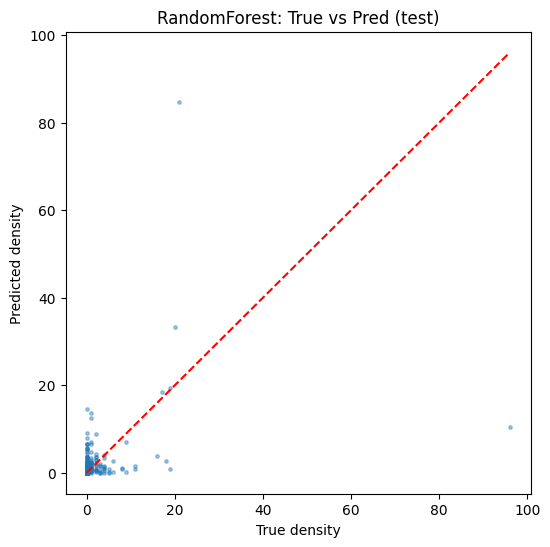

In [18]:
#figure
plt.figure(figsize=(6,6))
plt.scatter(y_test_orig, y_pred_orig, s=6, alpha=0.4)
mn = min(y_test_orig.min(), y_pred_orig.min())
mx = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([mn,mx],[mn,mx], 'r--')
plt.xlabel("True density"); plt.ylabel("Predicted density")
plt.title("RandomForest: True vs Pred (test)")
plt.show()

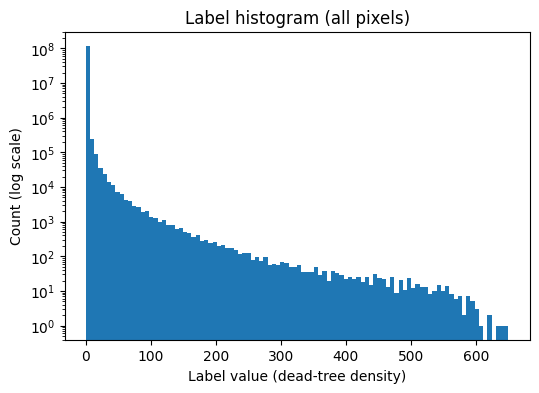

P50:  0.0
P75:  0.0
P90:  0.0
P95:  0.0
P99:  2.0
P99.9:  21.0


In [19]:
y = Y_flat  # e.g. flattened label from raster

plt.figure(figsize=(6,4))
plt.hist(y, bins=100, log=True)   # log scale on count to see tails
plt.xlabel('Label value (dead-tree density)')
plt.ylabel('Count (log scale)')
plt.title('Label histogram (all pixels)')
plt.show()

# Percentile summary
for q in [50,75,90,95,99,99.9]:
    print(f"P{q}: ", np.percentile(y, q))

Pixels: zeros=116,613,420, nonzeros=2,292,552, total=118,905,972
Will keep up to 2000 zeros (max_zero_frac=0.1)
Nonzero target samples: 18000
Final sampled count: 20000 zeros kept: 8610


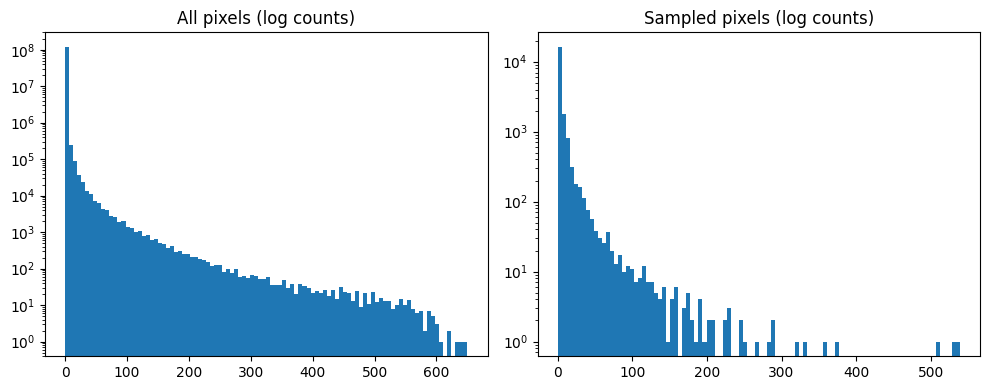

Train/test sizes: 16000 4000


In [30]:
N_SAMPLES_TOTAL = 20000       
max_zero_frac = 0.10         
n_bins = 8                   
random_state = 42
zero_eps = 1e-6              

rng = np.random.default_rng(random_state)

zero_mask = (Y_flat <= zero_eps)
nonzero_mask = ~zero_mask

zero_idx = np.nonzero(zero_mask)[0]
nonzero_idx = np.nonzero(nonzero_mask)[0]
n_zero_total = len(zero_idx)
n_nonzero_total = len(nonzero_idx)
print(f"Pixels: zeros={n_zero_total:,}, nonzeros={n_nonzero_total:,}, total={len(Y_flat):,}")


max_zeros_keep = int(np.round(N_SAMPLES_TOTAL * max_zero_frac))
zeros_to_keep = min(max_zeros_keep, n_zero_total)
print(f"Will keep up to {zeros_to_keep} zeros (max_zero_frac={max_zero_frac})")


if zeros_to_keep > 0 and n_zero_total > 0:
    chosen_zeros = rng.choice(zero_idx, size=zeros_to_keep, replace=(zeros_to_keep > n_zero_total))
else:
    chosen_zeros = np.array([], dtype=int)


nonzero_target = N_SAMPLES_TOTAL - len(chosen_zeros)
nonzero_target = max(nonzero_target, 0)
print("Nonzero target samples:", nonzero_target)

if nonzero_target == 0:
    chosen_nonzero = np.array([], dtype=int)
else:
    nonzero_values = Y_flat[nonzero_idx]
    # if very few nonzeros, just sample them all
    if len(nonzero_values) <= n_bins:
        chosen_nonzero = nonzero_idx  # keep all if small
    else:
        qs = np.linspace(0, 100, n_bins + 1)
        edges = np.percentile(nonzero_values, qs)
        chosen_list = []
        # allocate roughly equal number per bin
        per_bin = int(np.ceil(nonzero_target / n_bins))
        for i in range(n_bins):
            lo = edges[i]
            hi = edges[i+1]
            if i == n_bins - 1:
                mask = (nonzero_values >= lo) & (nonzero_values <= hi)
            else:
                mask = (nonzero_values >= lo) & (nonzero_values < hi)
            idxs_in_bin = nonzero_idx[mask]
            if idxs_in_bin.size == 0:
                continue
            k = min(per_bin, idxs_in_bin.size)
            pick = rng.choice(idxs_in_bin, size=k, replace=(k > idxs_in_bin.size))
            chosen_list.append(pick)
        if len(chosen_list) == 0:
            chosen_nonzero = np.array([], dtype=int)
        else:
            chosen_nonzero = np.concatenate(chosen_list)
        if chosen_nonzero.size > nonzero_target:
            chosen_nonzero = rng.choice(chosen_nonzero, size=nonzero_target, replace=False)


chosen_idx = np.concatenate([chosen_zeros, chosen_nonzero]) if (len(chosen_zeros) or len(chosen_nonzero)) else np.array([], dtype=int)


if chosen_idx.size < N_SAMPLES_TOTAL:
    need = N_SAMPLES_TOTAL - chosen_idx.size
    available = np.setdiff1d(np.arange(Y_flat.shape[0]), chosen_idx)
    if available.size > 0:
        extra = rng.choice(available, size=min(need, available.size), replace=False)
        chosen_idx = np.concatenate([chosen_idx, extra])


rng.shuffle(chosen_idx)
print("Final sampled count:", chosen_idx.size, "zeros kept:", np.sum(Y_flat[chosen_idx] <= zero_eps))


X_sel = X_flat[chosen_idx]
Y_sel = Y_flat[chosen_idx]


# Now proceed with train/test split and modeling as before:
X_train, X_test, y_train, y_test = train_test_split(X_sel, Y_sel, test_size=0.2, random_state=random_state)
print("Train/test sizes:", X_train.shape[0], X_test.shape[0])


In [31]:
rng = np.random.default_rng(random_state)

zero_mask     = (Y_flat <= zero_eps)
nonzero_mask  = ~zero_mask

zero_idx      = np.nonzero(zero_mask)[0]
nonzero_idx   = np.nonzero(nonzero_mask)[0]

print(f"Zeros: {len(zero_idx):,}, Non-zeros: {len(nonzero_idx):,}")

# ---- limit zeros to max_zero_frac ----
max_zeros_keep = int(N_SAMPLES_TOTAL * max_zero_frac)
zeros_to_keep  = min(max_zeros_keep, len(zero_idx))
chosen_zeros   = rng.choice(zero_idx, zeros_to_keep, replace=False)
print("Keeping zeros:", zeros_to_keep)

# ---- sample non-zero pixels in quantile bins ----
nonzero_target = N_SAMPLES_TOTAL - zeros_to_keep

nonzero_values = Y_flat[nonzero_idx]
chosen_nonzero = []

if len(nonzero_idx) > 0:
    # compute quantile edges
    qs = np.linspace(0, 100, n_bins + 1)
    edges = np.percentile(nonzero_values, qs)

    per_bin = int(np.ceil(nonzero_target / n_bins))

    for i in range(n_bins):
        lo, hi = edges[i], edges[i+1]
        if i == n_bins - 1:
            mask = (nonzero_values >= lo) & (nonzero_values <= hi)
        else:
            mask = (nonzero_values >= lo) & (nonzero_values < hi)

        idx_bin = nonzero_idx[mask]
        if idx_bin.size == 0:
            continue

        k = min(per_bin, idx_bin.size)
        pick = rng.choice(idx_bin, k, replace=False)
        chosen_nonzero.append(pick)

chosen_nonzero = np.concatenate(chosen_nonzero) if len(chosen_nonzero) else np.array([], dtype=int)


chosen_idx = np.concatenate([chosen_zeros, chosen_nonzero])
rng.shuffle(chosen_idx)

# ---- final sample arrays ----
X_sel = X_flat[chosen_idx]
Y_sel = Y_flat[chosen_idx]

print("Final sampled count:", X_sel.shape[0])
print("Zero fraction in sample:", np.mean(Y_sel <= zero_eps))


Zeros: 116,613,420, Non-zeros: 2,292,552
Keeping zeros: 2000
Final sampled count: 13250
Zero fraction in sample: 0.1509433962264151


In [33]:

if LOG_TRANSFORM:
    eps = 1e-6
    Y_sel_trans = np.log(Y_sel + eps)
else:
    Y_sel_trans = Y_sel.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, Y_sel_trans, test_size=0.2, random_state=random_state
)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 10600 Test size: 2650


In [34]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


In [35]:
rf = RandomForestRegressor(
    n_estimators=RF_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    n_jobs=-1,
    random_state=random_state
)
rf.fit(X_train_s, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
y_pred_test = rf.predict(X_test_s)

# invert log-transform if applied
if LOG_TRANSFORM:
    y_test_orig = np.exp(y_test) - eps
    y_pred_orig = np.exp(y_pred_test) - eps
else:
    y_test_orig = y_test
    y_pred_orig = y_pred_test

rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae  = mean_absolute_error(y_test_orig, y_pred_orig)
r2   = r2_score(y_test_orig, y_pred_orig)

print(f"RMSE={rmse:.4f}, MAE={mae:.4f}, R²={r2:.4f}")


RMSE=17.0263, MAE=5.6712, R²=0.1609


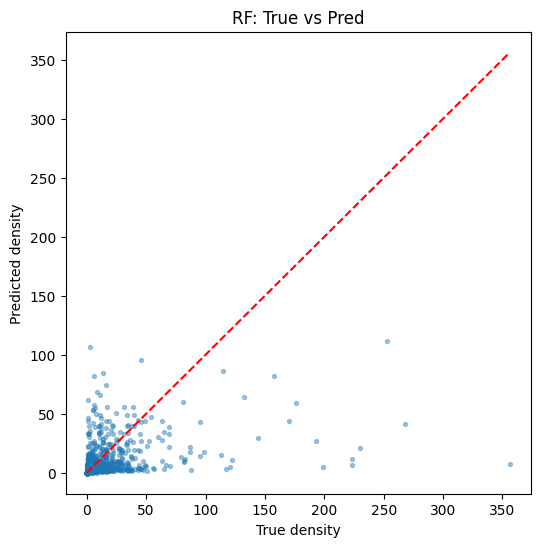

In [37]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_orig, y_pred_orig, s=8, alpha=0.4)
mn = min(y_test_orig.min(), y_pred_orig.min())
mx = max(y_test_orig.max(), y_pred_orig.max())
plt.plot([mn,mx],[mn,mx],'r--')
plt.xlabel("True density")
plt.ylabel("Predicted density")
plt.title("RF: True vs Pred")
plt.show()


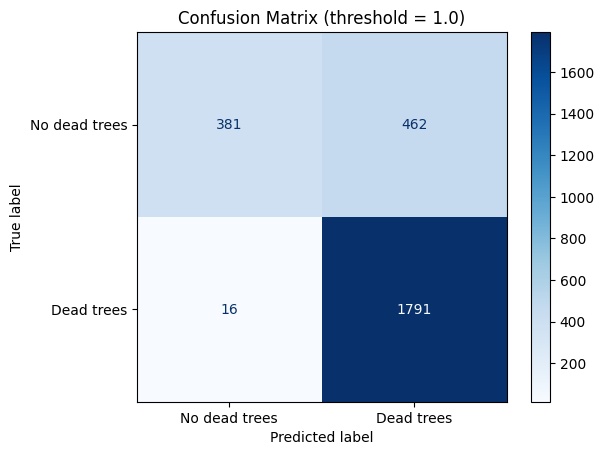

In [40]:
# choose a threshold, e.g. >0 means presence
threshold = 1.0   # CHANGE based on your data distribution

y_true_class = (y_test_orig > threshold).astype(int)
y_pred_class = (y_pred_orig > threshold).astype(int)

cm = confusion_matrix(y_true_class, y_pred_class)

disp = ConfusionMatrixDisplay(cm, display_labels=["No dead trees", "Dead trees"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix (threshold = {threshold})")
plt.show()